In [ ]:
#week 3 :  Univariate and Bivariate Visual Analysis 
#  • Distributions of daily hours, age bands, device usage 
#  • Compare screentime by gender, age band, and location type 
#  • Build bar charts, histograms, boxplots, and line plots 
 

In [7]:
#importing cleaned dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load cleaned dataset
df = pd.read_csv("Indian_Kids_Screen_Time_Cleaned.csv")

# standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Quick preview
print(df.head())


   age  gender  avg_daily_screen_time_hr primary_device  \
0   14    male                      3.99     smartphone   
1   11  female                      4.61         laptop   
2   18  female                      3.73             tv   
3   15  female                      1.21         laptop   
4   12  female                      5.89     smartphone   

   exceeded_recommended_limit  educational_to_recreational_ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           health_impacts urban_or_rural age_band age_group  \
0  poor sleep, eye strain          urban    12–15      Teen   
1              poor sleep          urban     8–11  Pre-Teen   
2              poor sleep          urban    16–

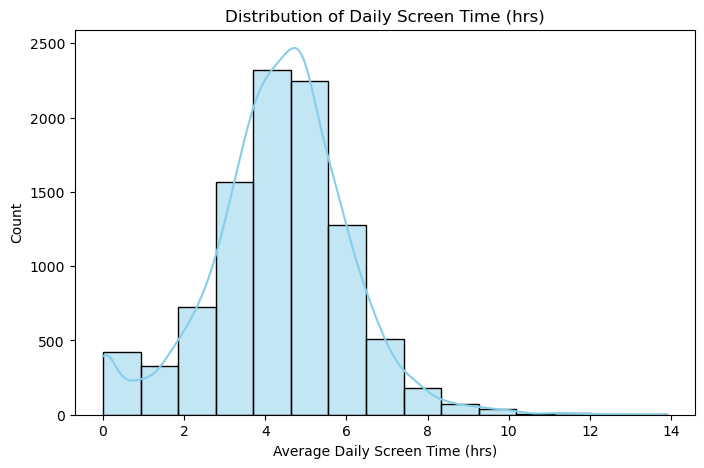

In [9]:
#Distribution of Daily Screen Time 

plt.figure(figsize=(8,5))
sns.histplot(df['avg_daily_screen_time_hr'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Daily Screen Time (hrs)")
plt.xlabel("Average Daily Screen Time (hrs)")
plt.ylabel("Count")
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_11060\1248755434.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_band', data=df, palette='viridis')


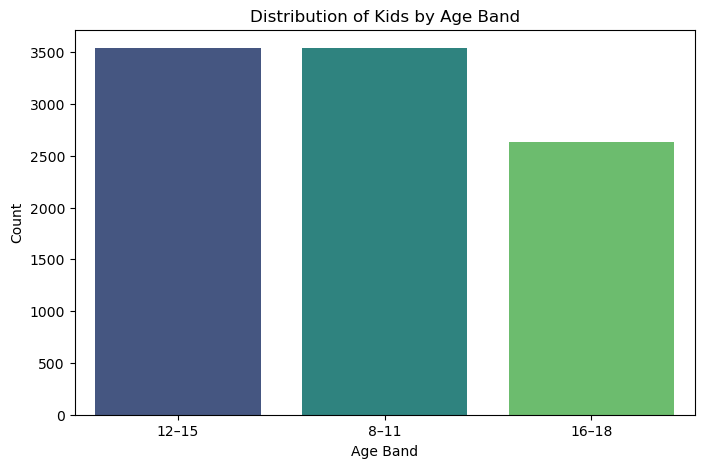

In [11]:
#Distribution of Kids by Age Band

plt.figure(figsize=(8,5))
sns.countplot(x='age_band', data=df, palette='viridis')
plt.title("Distribution of Kids by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_11060\3871689116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='primary_device', data=df, order=df['primary_device'].value_counts().index, palette='cool')


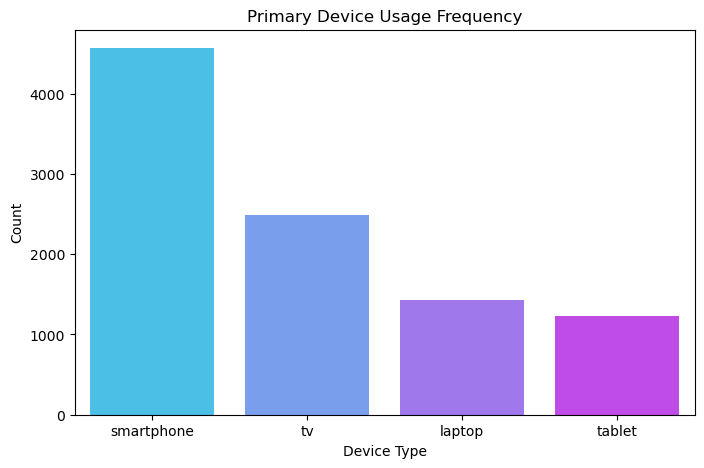

In [13]:
#Primary Device Usage Frequency

plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', data=df, order=df['primary_device'].value_counts().index, palette='cool')
plt.title("Primary Device Usage Frequency")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()


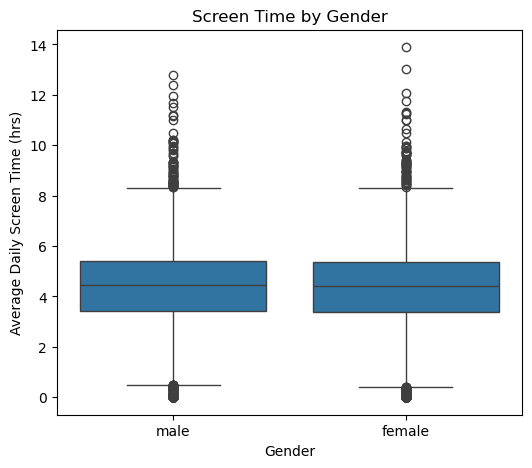

In [15]:
#Screen Time by Gender

plt.figure(figsize=(6,5))
sns.boxplot(x='gender', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.show()



C:\Users\hp\AppData\Local\Temp\ipykernel_11060\4038706210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_band', y='avg_daily_screen_time_hr', data=df, palette='plasma')


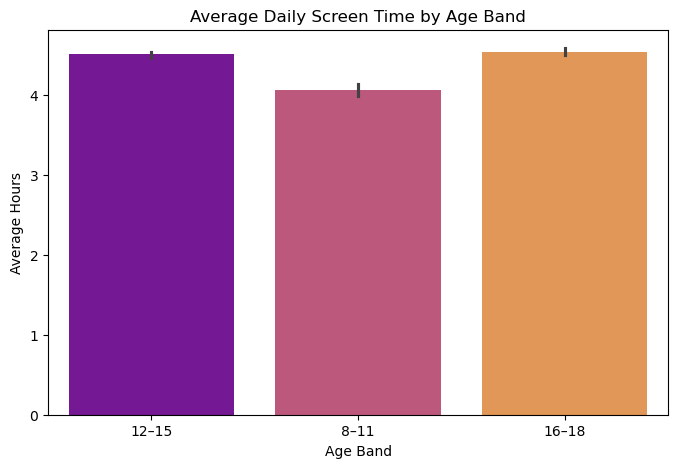

In [17]:
#Average Daily Screen Time by Age Band

plt.figure(figsize=(8,5))
sns.barplot(x='age_band', y='avg_daily_screen_time_hr', data=df, palette='plasma')
plt.title("Average Daily Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Hours")
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_11060\3963622699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='urban_or_rural', y='avg_daily_screen_time_hr', data=df, palette='Spectral')


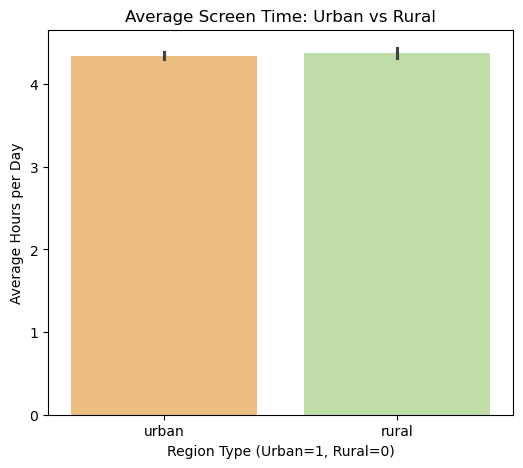

In [19]:
#Average Screen Time: Urban vs Rural

plt.figure(figsize=(6,5))
sns.barplot(x='urban_or_rural', y='avg_daily_screen_time_hr', data=df, palette='Spectral')
plt.title("Average Screen Time: Urban vs Rural")
plt.xlabel("Region Type (Urban=1, Rural=0)")
plt.ylabel("Average Hours per Day")
plt.show()


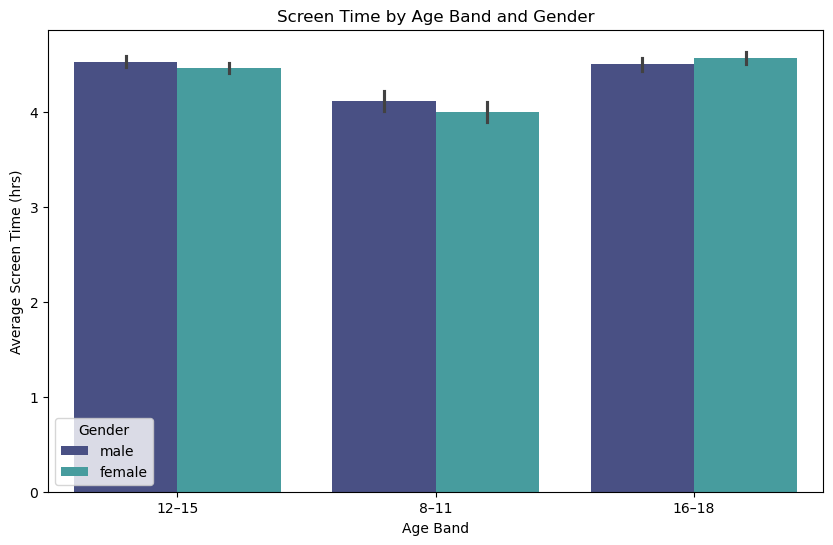

In [21]:
#Screen Time by Age Band and Gender

plt.figure(figsize=(10,6))
sns.barplot(x='age_band', y='avg_daily_screen_time_hr', hue='gender', data=df, palette='mako')
plt.title("Screen Time by Age Band and Gender")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (hrs)")
plt.legend(title="Gender")
plt.show()


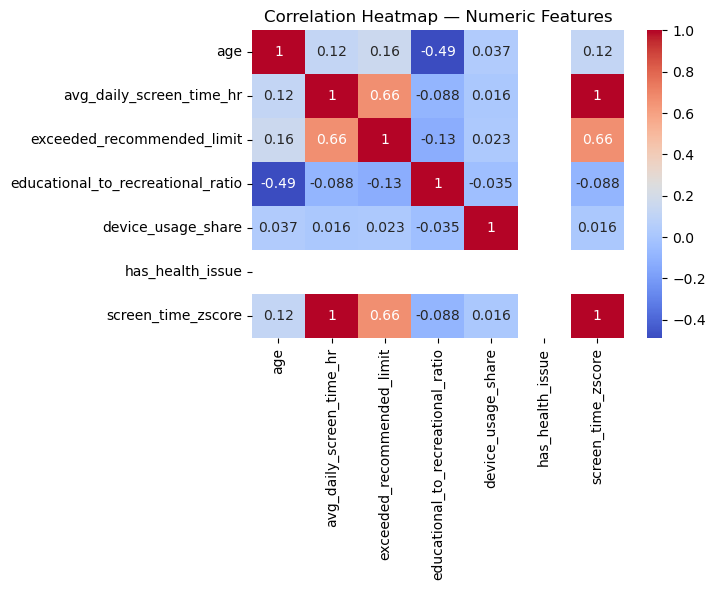

In [23]:
#Correlation Heatmap — Numeric Features

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap — Numeric Features")
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_11060\3487265067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='primary_device', y='avg_daily_screen_time_hr', data=df, estimator='mean', palette='viridis')


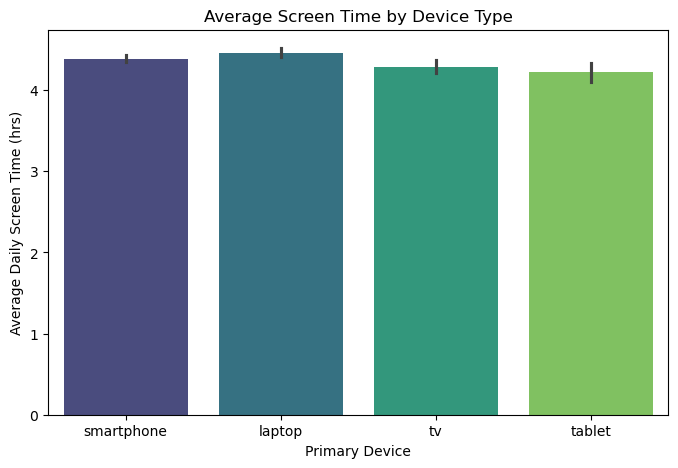

In [25]:
#Average Screen Time by Device Type

plt.figure(figsize=(8,5))
sns.barplot(x='primary_device', y='avg_daily_screen_time_hr', data=df, estimator='mean', palette='viridis')
plt.title("Average Screen Time by Device Type")
plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.show()


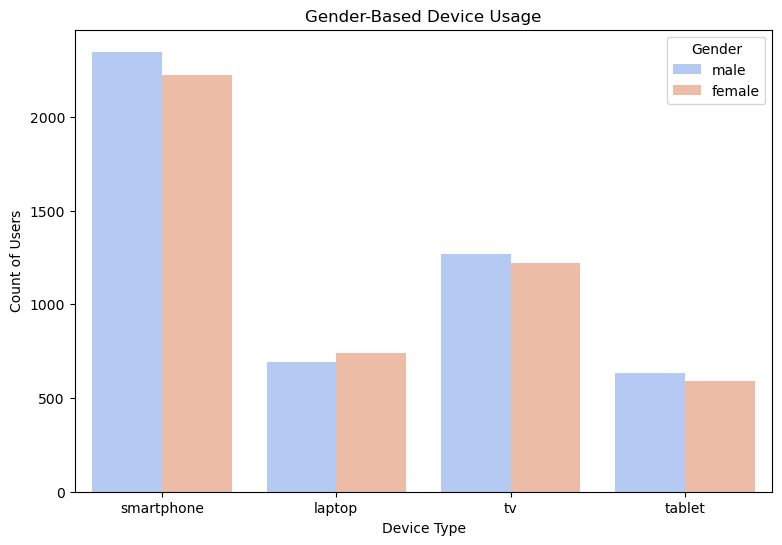

In [27]:
#Gender-Based Device Usage

plt.figure(figsize=(9,6))
sns.countplot(x='primary_device', hue='gender', data=df, palette='coolwarm')
plt.title("Gender-Based Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Count of Users")
plt.legend(title="Gender")
plt.show()


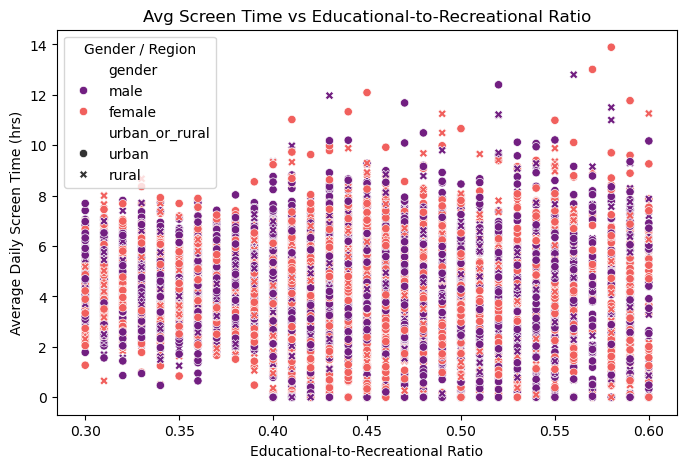

In [29]:
#Avg Screen Time vs Educational-to-Recreational Ratio

plt.figure(figsize=(8,5))
sns.scatterplot(x='educational_to_recreational_ratio', 
                y='avg_daily_screen_time_hr', 
                hue='gender', 
                style='urban_or_rural', 
                data=df, 
                palette='magma')
plt.title("Avg Screen Time vs Educational-to-Recreational Ratio")
plt.xlabel("Educational-to-Recreational Ratio")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Gender / Region", loc='best')
plt.show()


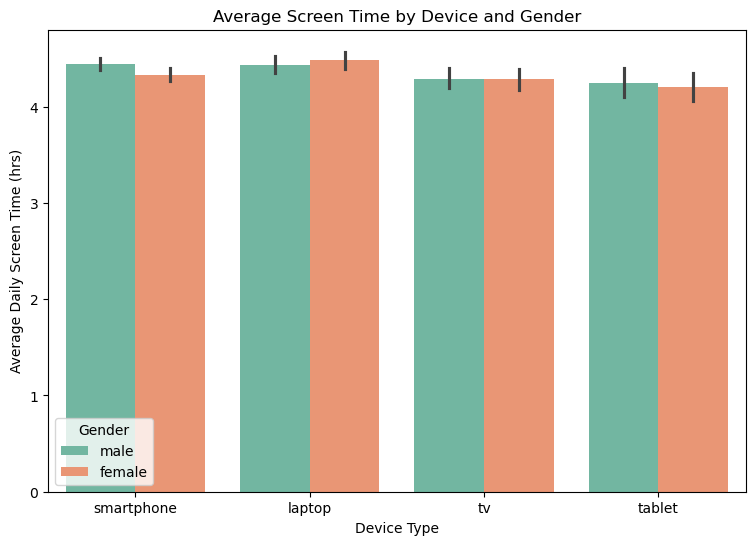

In [30]:
#Average Screen Time by Device and Gender

plt.figure(figsize=(9,6))
sns.barplot(x='primary_device', y='avg_daily_screen_time_hr', hue='gender', data=df, palette='Set2')
plt.title("Average Screen Time by Device and Gender")
plt.xlabel("Device Type")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Gender")
plt.show()


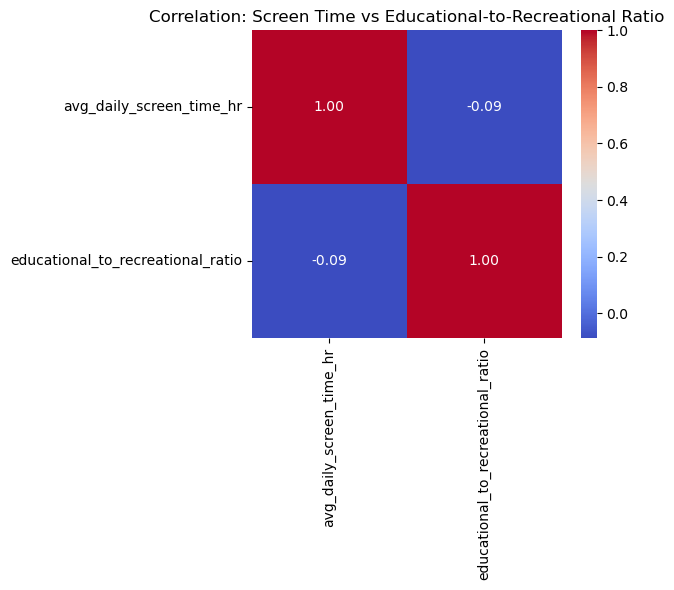

In [33]:
#Correlation: Screen Time vs Educational-to-Recreational Ratio

plt.figure(figsize=(5,4))
sns.heatmap(df[['avg_daily_screen_time_hr', 'educational_to_recreational_ratio']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Screen Time vs Educational-to-Recreational Ratio")
plt.show()


In [36]:
#Week 4: Device/Activity and Weekday/Weekend Analysis 
#• Compare device mix and activity categories across demographics 
#• Visualize weekday vs weekend differences and time patterns 
#Deliverables: Minimum 8 visuals + observations on peak usage cohorts 

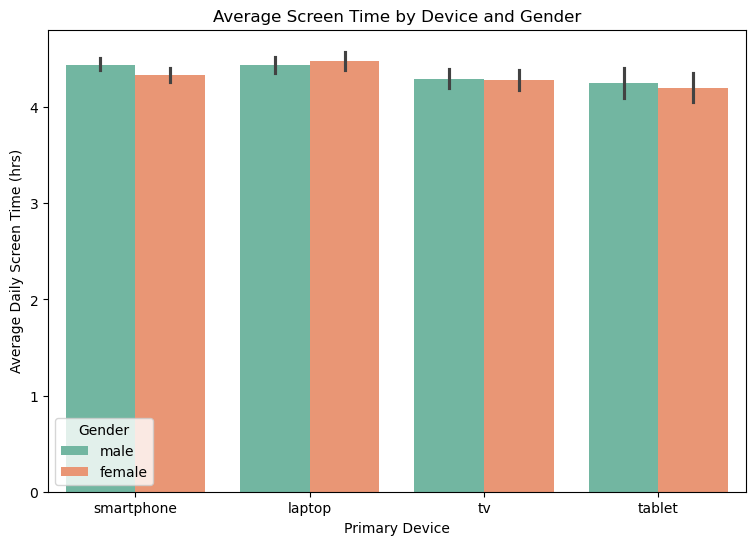

In [38]:
#Average Screen Time by Device and Gender

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.figure(figsize=(9,6))
sns.barplot(x='primary_device', y='avg_daily_screen_time_hr', hue='gender', data=df, palette='Set2')
plt.title("Average Screen Time by Device and Gender")
plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Gender")
plt.show()


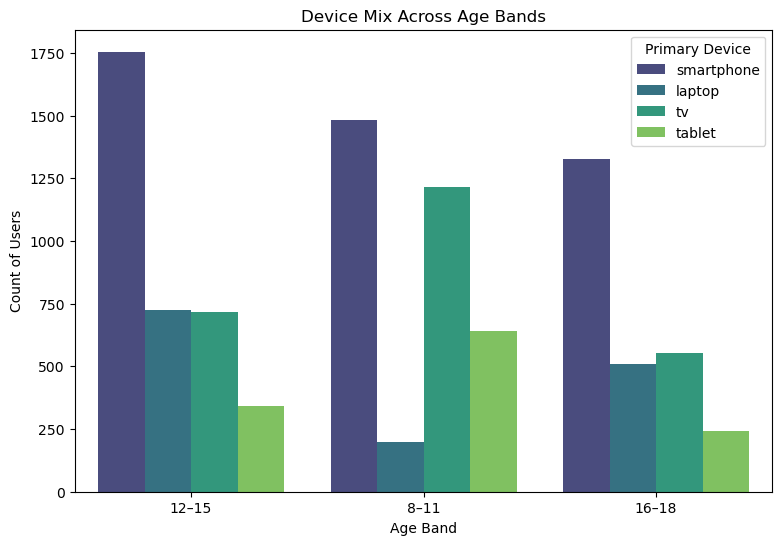

In [40]:
#Device Mix Across Age Bands

plt.figure(figsize=(9,6))
sns.countplot(x='age_band', hue='primary_device', data=df, palette='viridis')
plt.title("Device Mix Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count of Users")
plt.legend(title="Primary Device")
plt.show()


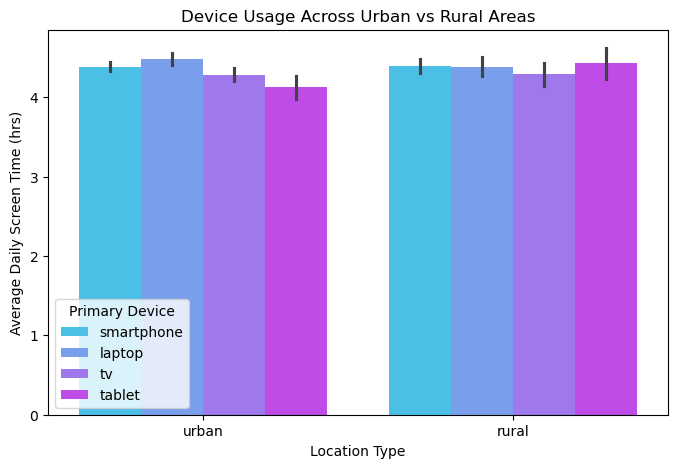

In [42]:
#Device Usage Across Urban vs Rural Areas

plt.figure(figsize=(8,5))
sns.barplot(x='urban_or_rural', y='avg_daily_screen_time_hr', hue='primary_device', data=df, palette='cool')
plt.title("Device Usage Across Urban vs Rural Areas")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Primary Device")
plt.show()


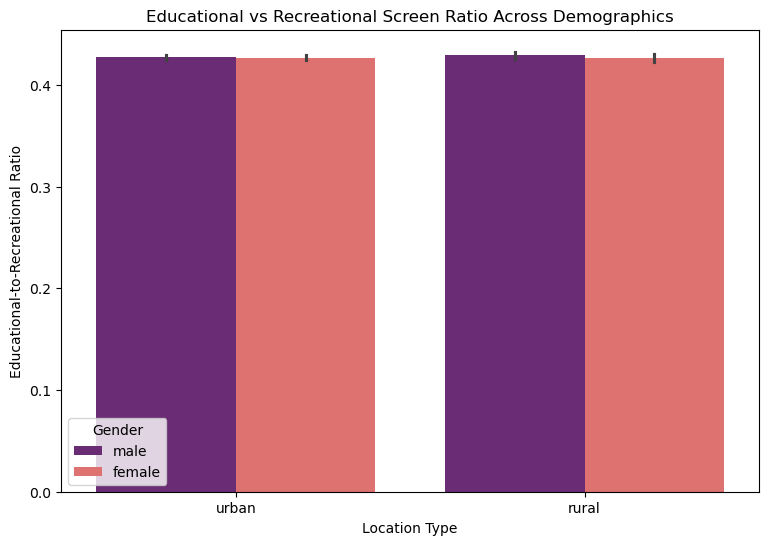

In [44]:
#Educational vs Recreational Screen Ratio Across Demographics

plt.figure(figsize=(9,6))
sns.barplot(x='urban_or_rural', y='educational_to_recreational_ratio', hue='gender', data=df, palette='magma')
plt.title("Educational vs Recreational Screen Ratio Across Demographics")
plt.xlabel("Location Type")
plt.ylabel("Educational-to-Recreational Ratio")
plt.legend(title="Gender")
plt.show()


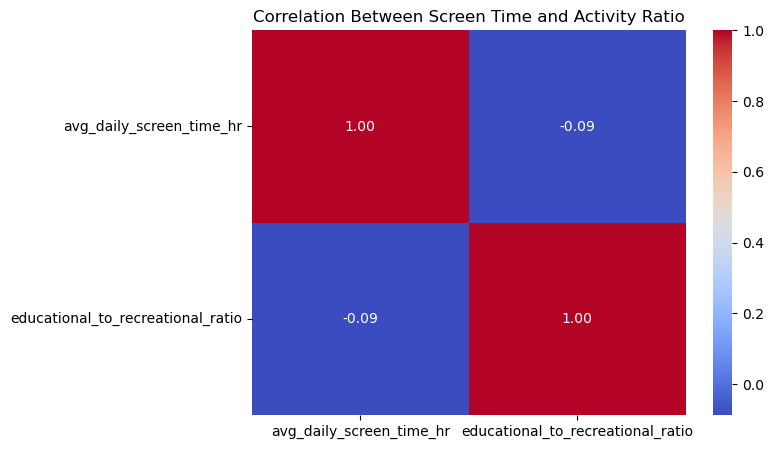

In [46]:
#Correlation Between Screen Time and Activity Ratio

plt.figure(figsize=(7,5))
sns.heatmap(df[['avg_daily_screen_time_hr',
                'educational_to_recreational_ratio']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Screen Time and Activity Ratio")
plt.show()


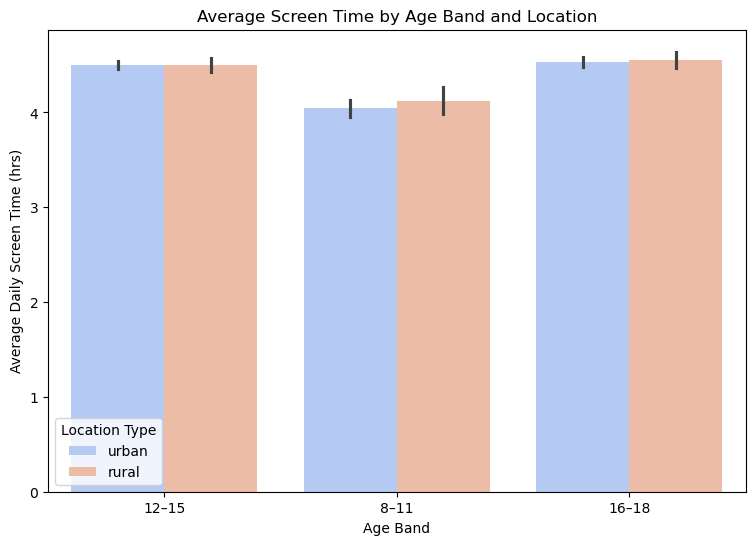

In [48]:
#Average Screen Time by Age Band and Location

plt.figure(figsize=(9,6))
sns.barplot(x='age_band', y='avg_daily_screen_time_hr', hue='urban_or_rural', data=df, palette='coolwarm')
plt.title("Average Screen Time by Age Band and Location")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Location Type")
plt.show()


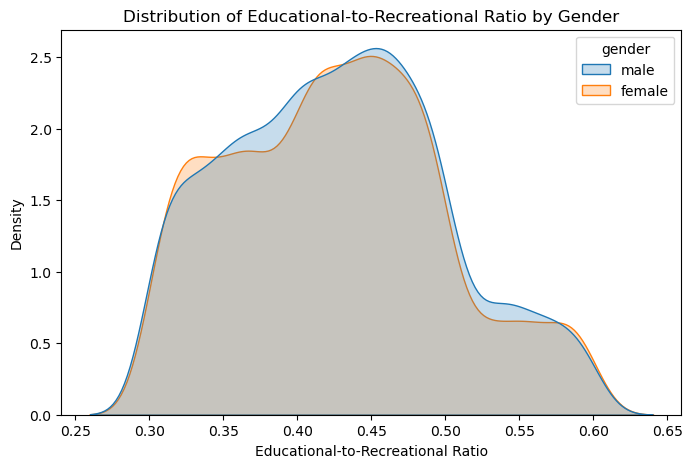

In [50]:
#Distribution of Educational-to-Recreational Ratio by Gender

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='educational_to_recreational_ratio', hue='gender', fill=True)
plt.title("Distribution of Educational-to-Recreational Ratio by Gender")
plt.xlabel("Educational-to-Recreational Ratio")
plt.ylabel("Density")
plt.show()


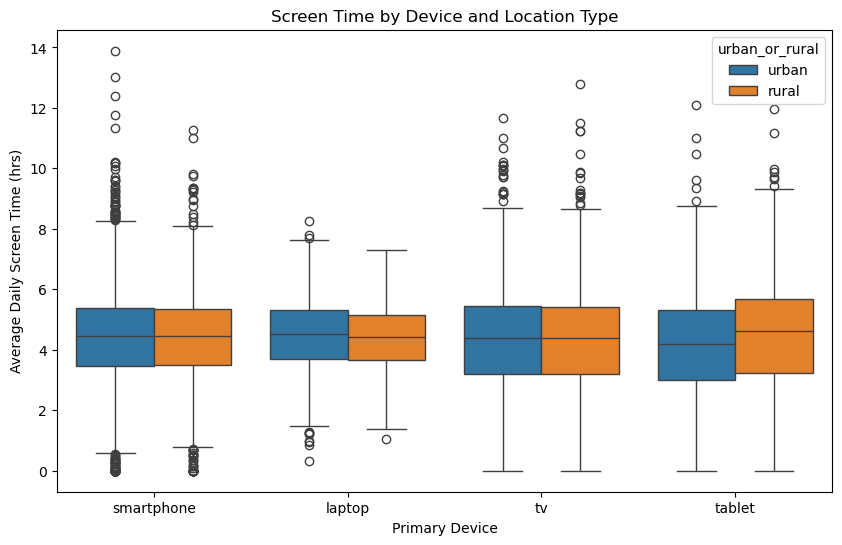

In [52]:
#Screen Time by Device and Location Type

plt.figure(figsize=(10,6))
sns.boxplot(x='primary_device', y='avg_daily_screen_time_hr', hue='urban_or_rural', data=df)
plt.title("Screen Time by Device and Location Type")
plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.show()


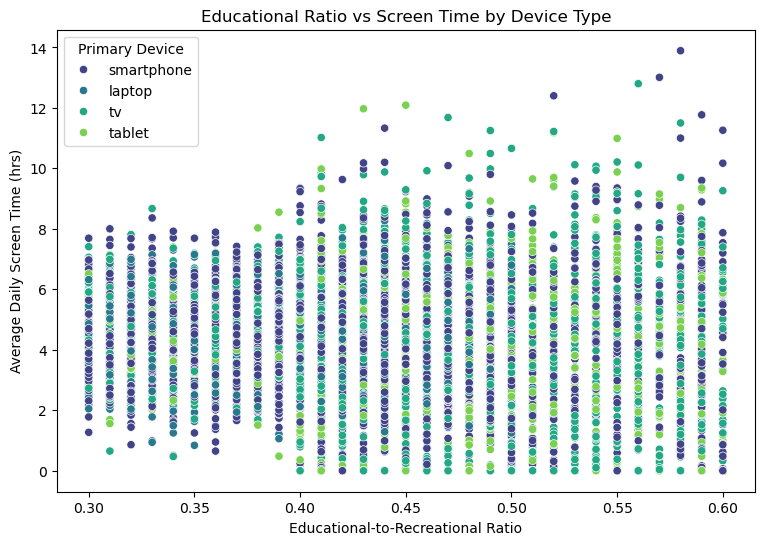

In [54]:
#Educational Ratio vs Screen Time by Device Type

plt.figure(figsize=(9,6))
sns.scatterplot(x='educational_to_recreational_ratio', 
                y='avg_daily_screen_time_hr', 
                hue='primary_device', 
                data=df, 
                palette='viridis')
plt.title("Educational Ratio vs Screen Time by Device Type")
plt.xlabel("Educational-to-Recreational Ratio")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.legend(title="Primary Device")
plt.show()


In [56]:
device_avg = df.groupby('primary_device')['avg_daily_screen_time_hr'].mean().sort_values(ascending=False)
print(device_avg)


primary_device
laptop        4.459086
smartphone    4.388925
tv            4.287752
tablet        4.226005
Name: avg_daily_screen_time_hr, dtype: float64
